In [9]:
import os
import shutil

# === FOLDERS WHERE YOU EXTRACTED THE ZIPS ===
NONVPN_01_DIR = r"C:\Users\LENOVO\Downloads\NonVPN-PCAPs-01"
NONVPN_02_DIR = r"C:\Users\LENOVO\Downloads\NonVPN-PCAPs-02"
NONVPN_03_DIR = r"C:\Users\LENOVO\Downloads\NonVPN-PCAPs-03"
VPN_01_DIR    = r"C:\Users\LENOVO\Downloads\VPN-PCAPS-01"
VPN_02_DIR    = r"C:\Users\LENOVO\Downloads\VPN-PCAPs-02"

# Root directory where class folders will be created
OUTPUT_ROOT = r"C:\Users\LENOVO\Downloads\pcap_classes"

CLASS_MAP = {
    "email": {
        "nonvpn": [
            "email1a.pcap", "email1b.pcap",
            "email2a.pcap", "email2b.pcap",
        ],
        "vpn": [
            "vpn_email2a.pcap", "vpn_email2b.pcap",
        ],
    },
    "chat": {
        "nonvpn": [
            "aim_chat_3a.pcap", "aim_chat_3b.pcap",
            "AIMchat1.pcapng", "AIMchat2.pcapng",
            "ICQchat1.pcapng", "ICQchat2.pcapng",
            "icq_chat_3a.pcap", "icq_chat_3b.pcap",
            "gmailchat1.pcapng", "gmailchat2.pcapng", "gmailchat3.pcapng",
            "facebookchat1.pcapng", "facebookchat2.pcapng", "facebookchat3.pcapng",
            "facebook_chat_4a.pcap", "facebook_chat_4b.pcap",
            "hangouts_chat_4a.pcap", "hangout_chat_4b.pcap",
            "skype_chat1a.pcap", "skype_chat1b.pcap",
        ],
        "vpn": [
            "vpn_aim_chat1a.pcap", "vpn_aim_chat1b.pcap",
            "vpn_facebook_chat1a.pcap", "vpn_facebook_chat1b.pcap",
            "vpn_hangouts_chat1a.pcap", "vpn_hangouts_chat1b.pcap",
            "vpn_icq_chat1a.pcap", "vpn_icq_chat1b.pcap",
            "vpn_skype_chat1a.pcap", "vpn_skype_chat1b.pcap",
        ],
    },
    "streaming": {
        "nonvpn": [
            "netflix1.pcap", "netflix2.pcap", "netflix3.pcap", "netflix4.pcap",
            "youtube1.pcap", "youtube2.pcap", "youtube3.pcap",
            "youtube4.pcap", "youtube5.pcap", "youtube6.pcap",
            "youtubeHTML5_1.pcap",
            "vimeo1.pcap", "vimeo2.pcap", "vimeo3.pcap", "vimeo4.pcap",
            "spotify1.pcap", "spotify2.pcap", "spotify3.pcap", "spotify4.pcap",
        ],
        "vpn": [
            "vpn_netflix_A.pcap",
            "vpn_youtube_A.pcap",
            "vpn_vimeo_A.pcap", "vpn_vimeo_B.pcap",
            "vpn_spotify_A.pcap",
        ],
    },
    "file_transfer": {
        "nonvpn": [
            "ftps_down_1a.pcap", "ftps_down_1b.pcap",
            "ftps_up_2a.pcap", "ftps_up_2b.pcap",
            "scp1.pcapng",
            "scpDown1.pcap", "scpDown2.pcap", "scpDown3.pcap",
            "scpDown4.pcap", "scpDown5.pcap", "scpDown6.pcap",
            "scpUp1.pcap", "scpUp2.pcap", "scpUp3.pcap",
            "scpUp5.pcap", "scpUp6.pcap",
            "sftp_down_3a.pcap", "sftp_down_3b.pcap",
            "sftp_up_2a.pcap", "sftp_up_2b.pcap",
            "sftp1.pcapng", "sftpDown1.pcap", "sftpDown2.pcap",
            "sftpUp1.pcap",
            "skype_file1.pcap", "skype_file2.pcap",
            "skype_file3.pcap", "skype_file4.pcapng",
            "skype_file5.pcapng", "skype_file6.pcapng",
            "skype_file7.pcapng", "skype_file8.pcapng",
        ],
        "vpn": [
            "vpn_ftps_A.pcap", "vpn_ftps_B.pcap",
            "vpn_sftp_A.pcap", "vpn_sftp_B.pcap",
            "vpn_skype_files1a.pcap", "vpn_skype_files1b.pcap",
        ],
    },
    "voip": {
        "nonvpn": [
            "facebook_audio1a.pcap", "facebook_audio1b.pcapng",
            "facebook_audio2a.pcap", "facebook_audio2b.pcapng",
            "facebook_audio3.pcapng", "facebook_audio4.pcapng",
            "facebook_video1a.pcap", "facebook_video1b.pcapng",
            "facebook_video2a.pcap", "facebook_video2b.pcapng",
            "hangouts_audio1a.pcap", "hangouts_audio1b.pcapng",
            "hangouts_audio2a.pcap", "hangouts_audio2b.pcapng",
            "hangouts_audio3.pcapng", "hangouts_audio4.pcapng",
            "hangouts_video1b.pcapng",
            "hangouts_video2a.pcap", "hangouts_video2b.pcapng",
            "skype_audio1a.pcap", "skype_audio1b.pcapng",
            "skype_audio2a.pcap", "skype_audio2b.pcapng",
            "skype_audio3.pcapng", "skype_audio4.pcapng",
            "skype_video1a.pcap", "skype_video1b.pcapng",
            "skype_video2a.pcap", "skype_video2b.pcapng",
            "voipbuster_4a.pcap", "voipbuster_4b.pcap",
            "voipbuster1b.pcapng", "voipbuster2b.pcapng",
            "voipbuster3b.pcapng",
        ],
        "vpn": [
            "vpn_facebook_audio2.pcap",
            "vpn_hangouts_audio1.pcap", "vpn_hangouts_audio2.pcap",
            "vpn_skype_audio1.pcap", "vpn_skype_audio2.pcap",
            "vpn_voipbuster1a.pcap", "vpn_voipbuster1b.pcap",
        ],
    },
    "p2p": {
        "nonvpn": [
            # No non-VPN BitTorrent pcaps in your dataset
        ],
        "vpn": [
            "vpn_bittorrent.pcap",
        ],
    },
}

BASE_DIRS = {
    "nonvpn": [NONVPN_01_DIR, NONVPN_02_DIR, NONVPN_03_DIR],
    "vpn":    [VPN_01_DIR, VPN_02_DIR],
}

def ensure_dir(path: str):
    if not os.path.isdir(path):
        os.makedirs(path, exist_ok=True)

def find_file(filename: str, search_dirs):
    for base in search_dirs:
        full = os.path.join(base, filename)
        if os.path.isfile(full):
            return full
    return None

def classify_pcaps():
    # Create output directories
    for cls in CLASS_MAP.keys():
        for flag in ("vpn", "nonvpn"):
            out_dir = os.path.join(OUTPUT_ROOT, f"{flag}_{cls}", "pcaps")
            ensure_dir(out_dir)

    missing = []
    copied_count = {"vpn": {}, "nonvpn": {}}
    for cls in CLASS_MAP.keys():
        copied_count["vpn"][cls] = 0
        copied_count["nonvpn"][cls] = 0

    # Copy files to their classified folders
    for cls, cfg in CLASS_MAP.items():
        for flag, filenames in cfg.items():
            if not filenames:
                continue
            dest_dir = os.path.join(OUTPUT_ROOT, f"{flag}_{cls}", "pcaps")
            search_dirs = BASE_DIRS[flag]

            for fname in filenames:
                src = find_file(fname, search_dirs)
                if src is None:
                    missing.append((flag, cls, fname))
                    continue
                dst = os.path.join(dest_dir, fname)
                shutil.copy2(src, dst)
                copied_count[flag][cls] += 1
                print(f"✓ {flag.upper():7s} {cls:15s}: {fname}")

    # Print summary
    print("\n" + "=" * 80)
    print("CLASSIFICATION SUMMARY")
    print("=" * 80)
    
    print("\n--- NON-VPN TRAFFIC ---")
    total_nonvpn = 0
    for cls in sorted(CLASS_MAP.keys()):
        count = copied_count["nonvpn"][cls]
        total_nonvpn += count
        print(f"  nonvpn_{cls:15s}: {count:3d} files")
    print(f"  {'TOTAL NON-VPN':>19s}: {total_nonvpn:3d} files")
    
    print("\n--- VPN TRAFFIC ---")
    total_vpn = 0
    for cls in sorted(CLASS_MAP.keys()):
        count = copied_count["vpn"][cls]
        total_vpn += count
        print(f"  vpn_{cls:15s}: {count:3d} files")
    print(f"  {'TOTAL VPN':>19s}: {total_vpn:3d} files")
    
    print(f"\n{'GRAND TOTAL':>19s}: {total_vpn + total_nonvpn:3d} files")

    # Report missing files
    if missing:
        print("\n" + "=" * 80)
        print("MISSING FILES")
        print("=" * 80)
        print("These files were not found in the extracted directories:")
        for flag, cls, fname in missing:
            print(f"  [{flag:7s}] {cls:15s}: {fname}")
        print(f"\nTotal missing: {len(missing)} files")
    else:
        print("\n✅ All listed PCAPs were copied successfully!")
    
    print("\n" + "=" * 80)
    print(f"Output directory: {OUTPUT_ROOT}")
    print("=" * 80)

if __name__ == "__main__":
    print("=" * 80)
    print("PCAP CLASSIFICATION TOOL")
    print("=" * 80)
    print()
    classify_pcaps()
    print("\n✅ Classification complete!")

PCAP CLASSIFICATION TOOL

✓ NONVPN  email          : email1a.pcap
✓ NONVPN  email          : email1b.pcap
✓ NONVPN  email          : email2a.pcap
✓ NONVPN  email          : email2b.pcap
✓ VPN     email          : vpn_email2a.pcap
✓ VPN     email          : vpn_email2b.pcap
✓ NONVPN  chat           : aim_chat_3a.pcap
✓ NONVPN  chat           : aim_chat_3b.pcap
✓ NONVPN  chat           : AIMchat1.pcapng
✓ NONVPN  chat           : AIMchat2.pcapng
✓ NONVPN  chat           : ICQchat1.pcapng
✓ NONVPN  chat           : ICQchat2.pcapng
✓ NONVPN  chat           : icq_chat_3a.pcap
✓ NONVPN  chat           : icq_chat_3b.pcap
✓ NONVPN  chat           : gmailchat1.pcapng
✓ NONVPN  chat           : gmailchat2.pcapng
✓ NONVPN  chat           : gmailchat3.pcapng
✓ NONVPN  chat           : facebookchat1.pcapng
✓ NONVPN  chat           : facebookchat2.pcapng
✓ NONVPN  chat           : facebookchat3.pcapng
✓ NONVPN  chat           : facebook_chat_4a.pcap
✓ NONVPN  chat           : facebook_chat_4b.pcap
✓

In [1]:
pip install dpkt


  Using cached dpkt-1.9.8-py3-none-any.whl.metadata (1.7 kB)
Using cached dpkt-1.9.8-py3-none-any.whl (194 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import subprocess
from pathlib import Path

# ==========================================================
# CONFIGURATION
# ==========================================================

WIRESHARK_PATH = r"C:\Program Files\Wireshark"
EDITCAP_EXE = os.path.join(WIRESHARK_PATH, "editcap.exe")
INPUT_ROOT = r"C:\Users\LENOVO\Downloads\pcap_classes"

# ==========================================================
# CONVERSION FUNCTION
# ==========================================================

def convert_and_delete_pcapng(root_dir):
    """
    Convert all .pcapng files to .pcap using editcap
    Delete original .pcapng files after successful conversion
    """
    
    # Check if editcap exists
    if not os.path.exists(EDITCAP_EXE):
        print(f"ERROR: editcap.exe not found at {EDITCAP_EXE}")
        return
    
    print(f"Using editcap from: {EDITCAP_EXE}\n")
    
    # Collect all pcapng files
    pcapng_files = []
    for root, dirs, files in os.walk(root_dir):
        for filename in files:
            if filename.endswith('.pcapng'):
                pcapng_path = os.path.join(root, filename)
                pcapng_files.append(pcapng_path)
    
    if len(pcapng_files) == 0:
        print("No .pcapng files found!")
        return
    
    print(f"Found {len(pcapng_files)} .pcapng files to convert\n")
    
    converted = 0
    failed = 0
    deleted = 0
    
    for pcapng_path in pcapng_files:
        filename = os.path.basename(pcapng_path)
        pcap_path = pcapng_path.replace('.pcapng', '.pcap')
        
        # Skip if .pcap already exists
        if os.path.exists(pcap_path):
            print(f"⚠ Already exists, deleting pcapng: {filename}")
            try:
                os.remove(pcapng_path)
                deleted += 1
            except Exception as e:
                print(f"  Failed to delete: {e}")
            continue
        
        try:
            # Run editcap command
            result = subprocess.run([
                EDITCAP_EXE,
                pcapng_path,
                pcap_path
            ], 
            capture_output=True, 
            text=True,
            check=True,
            timeout=300)  # 5 minute timeout per file
            
            print(f"✓ Converted: {filename}")
            converted += 1
            
            # Delete original .pcapng file after successful conversion
            try:
                os.remove(pcapng_path)
                print(f"  → Deleted: {filename}")
                deleted += 1
            except Exception as e:
                print(f"  ⚠ Failed to delete {filename}: {e}")
            
        except subprocess.TimeoutExpired:
            print(f"✗ Timeout: {filename}")
            failed += 1
            
        except subprocess.CalledProcessError as e:
            print(f"✗ Failed: {filename}")
            print(f"  Error: {e.stderr}")
            failed += 1
            
        except Exception as e:
            print(f"✗ Unexpected error for {filename}: {e}")
            failed += 1
    
    print(f"\n{'='*60}")
    print(f"CONVERSION COMPLETE")
    print(f"{'='*60}")
    print(f"✓ Converted: {converted}")
    print(f"✗ Failed: {failed}")
    print(f"🗑 Deleted: {deleted}")
    print(f"{'='*60}\n")

# ==========================================================
# MAIN
# ==========================================================

if __name__ == "__main__":
    
    print("="*60)
    print("PCAPNG to PCAP Converter")
    print("="*60)
    print(f"Input directory: {INPUT_ROOT}")
    print(f"Editcap path: {EDITCAP_EXE}")
    print("="*60)
    
    # Ask for confirmation
    response = input("\nThis will DELETE original .pcapng files after conversion.\nContinue? (yes/no): ")
    
    if response.lower() in ['yes', 'y']:
        print("\nStarting conversion...\n")
        convert_and_delete_pcapng(INPUT_ROOT)
    else:
        print("Conversion cancelled.")

PCAPNG to PCAP Converter
Input directory: C:\Users\LENOVO\Downloads\pcap_classes
Editcap path: C:\Program Files\Wireshark\editcap.exe

Starting conversion...

Using editcap from: C:\Program Files\Wireshark\editcap.exe

Found 38 .pcapng files to convert

✓ Converted: AIMchat1.pcapng
  → Deleted: AIMchat1.pcapng
✓ Converted: AIMchat2.pcapng
  → Deleted: AIMchat2.pcapng
✓ Converted: facebookchat1.pcapng
  → Deleted: facebookchat1.pcapng
✓ Converted: facebookchat2.pcapng
  → Deleted: facebookchat2.pcapng
✓ Converted: facebookchat3.pcapng
  → Deleted: facebookchat3.pcapng
✓ Converted: gmailchat1.pcapng
  → Deleted: gmailchat1.pcapng
✓ Converted: gmailchat2.pcapng
  → Deleted: gmailchat2.pcapng
✓ Converted: gmailchat3.pcapng
  → Deleted: gmailchat3.pcapng
✓ Converted: ICQchat1.pcapng
  → Deleted: ICQchat1.pcapng
✓ Converted: ICQchat2.pcapng
  → Deleted: ICQchat2.pcapng
✓ Converted: scp1.pcapng
  → Deleted: scp1.pcapng
✓ Converted: sftp1.pcapng
  → Deleted: sftp1.pcapng
✓ Converted: skype_fil

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import classification_report

# ===============================
# 1️⃣ Dataset loader for all classes
# ===============================
class TrafficIDXDatasetAll(Dataset):
    def __init__(self, images_file, labels_file):
        # Read labels (skip 8-byte header)
        with open(labels_file, 'rb') as f:
            y = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
        # Read images (skip 16-byte header)
        with open(images_file, 'rb') as f:
            X = np.frombuffer(f.read(), dtype=np.uint8, offset=16)

        num_samples = len(y)
        X = X.reshape((num_samples,28,28)).astype(np.float32)/255.0

        self.X = X[:, np.newaxis, :, :]  # add channel
        self.y = y  # labels 0–10

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# ===============================
# 2️⃣ Small CNN for 28x28 images
# ===============================
class SmallCNN(nn.Module):
    def __init__(self, num_classes=11):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*3*3,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ===============================
# 3️⃣ Load datasets
# ===============================
train_dataset = TrafficIDXDatasetAll(
    "C:/Users/LENOVO/Downloads/iscx_vpn_train_images.idx",
    "C:/Users/LENOVO/Downloads/iscx_vpn_train_labels.idx"
)
test_dataset = TrafficIDXDatasetAll(
    "C:/Users/LENOVO/Downloads/iscx_vpn_test_images.idx",
    "C:/Users/LENOVO/Downloads/iscx_vpn_test_labels.idx"
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ===============================
# 4️⃣ Compute class weights for imbalance
# ===============================
unique, counts = np.unique(train_dataset.y, return_counts=True)
class_counts = dict(zip(unique, counts))
total = sum(class_counts.values())
num_classes = len(class_counts)

weights = [total/(num_classes*class_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(weights,dtype=torch.float32)

# ===============================
# 5️⃣ Setup device, model, criterion, optimizer
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmallCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===============================
# 6️⃣ Training loop
# ===============================
epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0,0,0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        correct += (predicted==y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct/total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f} - Train Acc: {acc:.4f}")

# ===============================
# 7️⃣ Evaluation
# ===============================
model.eval()
all_preds, all_labels = [],[]
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs,1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, digits=4))

# ===============================
# 8️⃣ Display first 50 predictions
# ===============================
print("\n=== First 50 test predictions ===")
for i in range(min(50, len(all_labels))):
    print(f"True: {all_labels[i]} - Predicted: {all_preds[i]}")


Epoch 1/30 - Loss: 2.4855 - Train Acc: 0.0812
Epoch 2/30 - Loss: 2.1456 - Train Acc: 0.2507
Epoch 3/30 - Loss: 0.7907 - Train Acc: 0.7704
Epoch 4/30 - Loss: 0.1881 - Train Acc: 0.9701
Epoch 5/30 - Loss: 0.0588 - Train Acc: 0.9945
Epoch 6/30 - Loss: 0.0243 - Train Acc: 0.9991
Epoch 7/30 - Loss: 0.0114 - Train Acc: 0.9999
Epoch 8/30 - Loss: 0.0063 - Train Acc: 1.0000
Epoch 9/30 - Loss: 0.0041 - Train Acc: 1.0000
Epoch 10/30 - Loss: 0.0027 - Train Acc: 1.0000
Epoch 11/30 - Loss: 0.0019 - Train Acc: 1.0000
Epoch 12/30 - Loss: 0.0014 - Train Acc: 1.0000
Epoch 13/30 - Loss: 0.0011 - Train Acc: 1.0000
Epoch 14/30 - Loss: 0.0008 - Train Acc: 1.0000
Epoch 15/30 - Loss: 0.0006 - Train Acc: 1.0000
Epoch 16/30 - Loss: 0.0005 - Train Acc: 1.0000
Epoch 17/30 - Loss: 0.0004 - Train Acc: 1.0000
Epoch 18/30 - Loss: 0.0003 - Train Acc: 1.0000
Epoch 19/30 - Loss: 0.0003 - Train Acc: 1.0000
Epoch 20/30 - Loss: 0.0002 - Train Acc: 1.0000
Epoch 21/30 - Loss: 0.0002 - Train Acc: 1.0000
Epoch 22/30 - Loss: 0.

In [1]:
import os
import random
import numpy as np
from PIL import Image

# Configuration
TRAIN_ROOT = r"F:\USTC-TK2016-master\USTC-TK2016-master\4_Png\Train"
TARGET_COUNT = 8000

def apply_augmentation(image_path):
    """
    Opens an image, applies random shift and Gaussian noise, returns PIL Image
    """
    # Load image and convert to numpy array
    img = Image.open(image_path).convert('L') # Ensure grayscale
    img_array = np.array(img, dtype=np.float32)
    
    # 1. Random Shifting (1 to 2 pixels)
    shift_x = random.randint(-2, 2)
    shift_y = random.randint(-2, 2)
    img_array = np.roll(img_array, shift_x, axis=1)
    img_array = np.roll(img_array, shift_y, axis=0)
    
    # 2. Add Gaussian Noise (Standard Deviation of 2-5 for subtle static)
    noise = np.random.normal(0, 3, img_array.shape)
    img_array = img_array + noise
    
    # Clip values to stay in 0-255 range and convert back to uint8
    img_array = np.clip(img_array, 0, 255).astype(np.uint8)
    
    return Image.fromarray(img_array)

print(f"Starting Augmented Oversampling to {TARGET_COUNT} images per folder...")

# Get all class folders
folders = [d for d in os.listdir(TRAIN_ROOT) if os.path.isdir(os.path.join(TRAIN_ROOT, d))]

for folder in folders:
    folder_path = os.path.join(TRAIN_ROOT, folder)
    
    # Get list of original PNG files
    files = [f for f in os.listdir(folder_path) if f.lower().endswith('.png') and "_aug_" not in f]
    current_count = len([f for f in os.listdir(folder_path) if f.lower().endswith('.png')])
    
    if len(files) == 0:
        print(f"Skipping {folder}: No original files found.")
        continue

    if current_count < TARGET_COUNT:
        print(f"Augmenting {folder}: {current_count} -> {TARGET_COUNT}")
        
        num_to_add = TARGET_COUNT - current_count
        
        for i in range(num_to_add):
            # Pick a random original file to use as a base
            source_file = random.choice(files)
            source_path = os.path.join(folder_path, source_file)
            
            # Apply transformations
            augmented_img = apply_augmentation(source_path)
            
            # Save with a new name
            new_name = f"{os.path.splitext(source_file)[0]}_aug_{i}.png"
            augmented_img.save(os.path.join(folder_path, new_name))
            
            if (i + 1) % 500 == 0:
                print(f"   Generated {i + 1} images...")
            
    else:
        print(f"Skipping {folder}: Already has {current_count} images.")

print("\n🎉 Success! All folders now have 4000+ images with unique augmented variations.")

Starting Augmented Oversampling to 8000 images per folder...
Augmenting nonvpn_chat: 5901 -> 8000
   Generated 500 images...
   Generated 1000 images...
   Generated 1500 images...
   Generated 2000 images...
Augmenting nonvpn_email: 6581 -> 8000
   Generated 500 images...
   Generated 1000 images...
Skipping nonvpn_file_transfer: Already has 9000 images.
Augmenting nonvpn_p2p: 6765 -> 8000
   Generated 500 images...
   Generated 1000 images...
Augmenting nonvpn_streaming: 1092 -> 8000
   Generated 500 images...
   Generated 1000 images...
   Generated 1500 images...
   Generated 2000 images...
   Generated 2500 images...
   Generated 3000 images...
   Generated 3500 images...
   Generated 4000 images...
   Generated 4500 images...
   Generated 5000 images...
   Generated 5500 images...
   Generated 6000 images...
   Generated 6500 images...
Skipping nonvpn_voip: Already has 9000 images.
Augmenting vpn_bittorrent: 429 -> 8000
   Generated 500 images...
   Generated 1000 images...
   Ge

In [ ]:
"""
fast_image_classifiers_capped.py - Fast Training with Accuracy Capped at 80–85%
=================================================================================
Intentionally constrained models to avoid exceeding ~85% validation accuracy.

Techniques used per model:
  1. Partial layer freezing  – backbone mostly frozen, only top layers trainable
  2. Strong Dropout          – higher dropout rates (0.4–0.6)
  3. Label Smoothing         – makes the model less overconfident
  4. Low learning rate       – slower convergence
  5. Fewer epochs            – stops before full convergence
  6. Smaller image size      – less detail available to the model
  7. No heavy augmentation   – simpler pipeline, less generalisation boost
"""

import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Global accuracy cap guard ─────────────────────────────────────────────────
ACC_CAP = 85.0   # hard ceiling – training stops if val_acc exceeds this


# =============================================================================
# HELPER – freeze all backbone parameters except the last `unfreeze_blocks`
# =============================================================================

def freeze_backbone(model_module, unfreeze_blocks: int = 1):
    """
    Freeze every parameter in `model_module`, then unfreeze the last
    `unfreeze_blocks` children so only a thin top layer trains.
    This alone cuts accuracy by 5-10 pp vs full fine-tuning.
    """
    for param in model_module.parameters():
        param.requires_grad = False

    children = list(model_module.children())
    for child in children[-unfreeze_blocks:]:
        for param in child.parameters():
            param.requires_grad = True


# =============================================================================
# CONSTRAINED MODEL DEFINITIONS
# =============================================================================

class MobileNetV3Classifier(nn.Module):
    """MobileNetV3 – backbone mostly frozen, heavy dropout head"""
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = models.mobilenet_v3_large(pretrained=pretrained)

        # Freeze all but the last 2 feature blocks
        freeze_backbone(self.model.features, unfreeze_blocks=2)

        # High-dropout head
        self.model.classifier = nn.Sequential(
            nn.Linear(960, 512),
            nn.Hardswish(),
            nn.Dropout(0.55),          # was 0.2 → now 0.55
            nn.Linear(512, num_classes)
        )
        self.name = "MobileNetV3"

    def forward(self, x):
        return self.model(x)


class EfficientNetB0Classifier(nn.Module):
    """EfficientNet-B0 – partial freeze + strong dropout"""
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=pretrained)

        # Freeze all but last 3 feature blocks
        freeze_backbone(self.model.features, unfreeze_blocks=3)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.50),          # was 0.2 → now 0.50
            nn.Linear(in_features, num_classes)
        )
        self.name = "EfficientNet-B0"

    def forward(self, x):
        return self.model(x)


class SqueezeNetClassifier(nn.Module):
    """SqueezeNet – naturally weak; add dropout to keep it modest"""
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = models.squeezenet1_1(pretrained=pretrained)

        # Freeze early fire modules
        freeze_backbone(self.model.features, unfreeze_blocks=2)

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.60),          # was 0.5 → now 0.60
            nn.Conv2d(512, num_classes, kernel_size=1),
            nn.AdaptiveAvgPool2d(1)
        )
        self.name = "SqueezeNet"

    def forward(self, x):
        return self.model(x).squeeze()


class ShuffleNetV2Classifier(nn.Module):
    """ShuffleNetV2 – freeze stage 2 & 3, strong FC dropout"""
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = models.shufflenet_v2_x1_0(pretrained=pretrained)

        # Freeze conv1, maxpool, stage2 → leave stage3+stage4 trainable
        layers_to_freeze = [
            self.model.conv1,
            self.model.maxpool,
            self.model.stage2,
        ]
        for layer in layers_to_freeze:
            for param in layer.parameters():
                param.requires_grad = False

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.50),
            nn.Linear(in_features, num_classes)
        )
        self.name = "ShuffleNetV2"

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.maxpool(x)
        x = self.model.stage2(x)
        x = self.model.stage3(x)
        x = self.model.stage4(x)
        x = self.model.conv5(x)
        x = x.mean([2, 3])
        return self.model.fc(x)


class MNASNetClassifier(nn.Module):
    """MNASNet – freeze most layers, high dropout"""
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = models.mnasnet1_0(pretrained=pretrained)

        # Freeze all layers in `layers` except last 3
        freeze_backbone(self.model.layers, unfreeze_blocks=3)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.55),          # was 0.2 → now 0.55
            nn.Linear(in_features, num_classes)
        )
        self.name = "MNASNet"

    def forward(self, x):
        return self.model(x)


# =============================================================================
# DATASET LOADER  (unchanged logic, smaller image fed via transform)
# =============================================================================

class FastImageDataset(Dataset):
    """Dataset loader – image size kept small (128 px) to limit accuracy."""
    def __init__(self, images_dir, transform=None, max_samples_per_class=None):
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.samples = []

        self.classes = sorted([d.name for d in self.images_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        print(f"Loading dataset from: {images_dir}")
        print(f"Found {len(self.classes)} classes")

        for class_name in tqdm(self.classes, desc="Loading images"):
            class_dir = self.images_dir / class_name
            if not class_dir.exists():
                continue

            images = list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpg"))

            if max_samples_per_class and len(images) > max_samples_per_class:
                images = np.random.choice(images, max_samples_per_class, replace=False)

            class_idx = self.class_to_idx[class_name]
            for img_path in images:
                self.samples.append((str(img_path), class_idx))

        print(f"Loaded {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# =============================================================================
# TRAINER  (label smoothing + early-stop above ACC_CAP)
# =============================================================================

class ConstrainedTrainer:
    """
    Trainer that:
      • Uses label smoothing (0.15) to stop overconfident predictions
      • Low learning rate (5e-4) for slow convergence
      • Stops an epoch early and skips further training if val_acc > ACC_CAP
    """
    def __init__(self, model, device, learning_rate=5e-4):
        self.model = model.to(device)
        self.device = device

        # Label smoothing reduces overconfident soft-max outputs
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

        # Only train unfrozen parameters
        trainable = [p for p in model.parameters() if p.requires_grad]
        self.optimizer = optim.AdamW(trainable, lr=learning_rate, weight_decay=5e-4)

        # Mild scheduler – does not aggressively boost LR
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=5, gamma=0.5   # halve LR every 5 epochs
        )
        self.scaler = GradScaler()

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss':   [], 'val_acc':   [],
            'epoch_time': []
        }

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        start = time.time()

        pbar = tqdm(train_loader, desc="Training", leave=False)
        for images, labels in pbar:
            images, labels = images.to(self.device), labels.to(self.device)

            with autocast():
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

            self.optimizer.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'acc':  f'{100.*correct/total:.2f}%'})

        return total_loss / len(train_loader), 100. * correct / total, time.time() - start

    def validate(self, val_loader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validating", leave=False):
                images, labels = images.to(self.device), labels.to(self.device)
                with autocast():
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total   += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        return total_loss / len(val_loader), 100. * correct / total

    def train(self, train_loader, val_loader, epochs=10):
        print(f"\n{'='*60}")
        print(f"Training {self.model.name}  [ACC cap: {ACC_CAP}%]")
        print(f"{'='*60}")
        print(f"Epochs: {epochs} | LR: {self.optimizer.param_groups[0]['lr']}")
        print(f"Label Smoothing: 0.15 | Dropout: high | Frozen backbone: yes")
        print(f"{'='*60}\n")

        best_val_acc = 0

        for epoch in range(1, epochs + 1):
            epoch_start = time.time()

            train_loss, train_acc, train_time = self.train_epoch(train_loader)
            val_loss,   val_acc              = self.validate(val_loader)

            self.scheduler.step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['epoch_time'].append(time.time() - epoch_start)

            print(f"\nEpoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
                  f"Time: {train_time:.1f}s")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(self.model.state_dict(), f"best_{self.model.name}.pth")
                print(f"  -> New best: {val_acc:.2f}%")

            # ── Hard cap guard ──────────────────────────────────────────────
            if val_acc > ACC_CAP:
                print(f"\n  [CAP] Val acc {val_acc:.2f}% exceeded {ACC_CAP}% cap.")
                print(f"  [CAP] Stopping training for {self.model.name} early.")
                break

        return self.history


# =============================================================================
# MODEL COMPARISON
# =============================================================================

def compare_models(models_list, train_loader, val_loader, epochs=10):
    results = []

    for model_class in models_list:
        print(f"\n{'='*80}")
        print(f"Training {model_class.__name__}")
        print(f"{'='*80}")

        num_classes = len(train_loader.dataset.classes)
        model = model_class(num_classes=num_classes, pretrained=True)

        trainer = ConstrainedTrainer(model, device, learning_rate=5e-4)
        history = trainer.train(train_loader, val_loader, epochs=epochs)

        results.append({
            'model':         model.name,
            'best_val_acc':  max(history['val_acc']),
            'final_val_acc': history['val_acc'][-1],
            'avg_epoch_time': np.mean(history['epoch_time']),
            'total_time':    sum(history['epoch_time']),
            'train_acc':     history['train_acc'][-1]
        })

    df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)

    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    print(df.to_string(index=False))
    return df


# =============================================================================
# MAIN
# =============================================================================

def main():
    images_dir = Path(r"E:\Edge-IIoTset dataset\processed_multimodal_dataset\3_images")
    batch_size = 128

    # ── Smaller image size (128 instead of 224) limits extractable detail ────
    IMAGE_SIZE = 128

    # ── Minimal augmentation – no heavy colour jitter or rotation boost ───────
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),          # mild flip only
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # ── Load datasets ─────────────────────────────────────────────────────────
    print("\n" + "="*80)
    print("LOADING DATASETS")
    print("="*80)

    train_dataset = FastImageDataset(
        images_dir / "Train",
        transform=train_transform,
        max_samples_per_class=3000      # fewer samples → less training signal
    )
    val_dataset = FastImageDataset(
        images_dir / "Test",
        transform=val_transform,
        max_samples_per_class=1000
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True, prefetch_factor=2)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=4, pin_memory=True)

    print(f"\nTrain samples: {len(train_dataset)}")
    print(f"Val samples  : {len(val_dataset)}")
    print(f"Classes      : {len(train_dataset.classes)}")
    print(f"Batch size   : {batch_size}")
    print(f"Image size   : {IMAGE_SIZE}×{IMAGE_SIZE}  ← reduced from 224")

    # ── Models to compare ─────────────────────────────────────────────────────
    models_to_compare = [
        MobileNetV3Classifier,
        EfficientNetB0Classifier,
        ShuffleNetV2Classifier,
        MNASNetClassifier,
        SqueezeNetClassifier
    ]

    comparison_df = compare_models(
        models_to_compare,
        train_loader,
        val_loader,
        epochs=10       # reduced from 15 – fewer epochs = less convergence
    )

    comparison_df.to_csv("model_comparison_results_capped.csv", index=False)
    print("\nResults saved to 'model_comparison_results_capped.csv'")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Model Comparison (Accuracy Capped ≤ 85%)", fontsize=14, fontweight='bold')

    models_names = comparison_df['model'].values
    times        = comparison_df['total_time'].values
    accs         = comparison_df['best_val_acc'].values

    axes[0].barh(models_names, times, color='skyblue')
    axes[0].set_xlabel('Total Training Time (s)')
    axes[0].set_title('Training Speed')

    bars = axes[1].barh(models_names, accs, color='lightcoral')
    axes[1].set_xlabel('Best Validation Accuracy (%)')
    axes[1].set_title('Accuracy (target: 80–85%)')
    axes[1].axvline(x=85, color='red', linestyle='--', linewidth=1.5, label='85% cap')
    axes[1].axvline(x=80, color='orange', linestyle='--', linewidth=1.5, label='80% floor')
    axes[1].legend()

    # Annotate bars
    for bar, acc in zip(bars, accs):
        axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{acc:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('model_comparison_capped.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "="*80)
    print("SUMMARY – CONSTRAINED ACCURACY RESULTS")
    print("="*80)
    for _, row in comparison_df.iterrows():
        flag = "✓ OK" if row['best_val_acc'] <= ACC_CAP else "✗ OVER CAP"
        print(f"  {row['model']:20s}  Val Acc: {row['best_val_acc']:5.2f}%  "
              f"Time: {row['total_time']:6.1f}s  [{flag}]")

    print(f"\nAll models constrained using:")
    print(f"  • Backbone freezing      (most pretrained weights locked)")
    print(f"  • High dropout           (0.50–0.60)")
    print(f"  • Label smoothing        (0.15)")
    print(f"  • Low learning rate      (5e-4, halved every 5 epochs)")
    print(f"  • Smaller input size     (128×128 instead of 224×224)")
    print(f"  • Fewer training samples (3 000 / class)")
    print(f"  • Fewer epochs           (10 instead of 15–30)")
    print(f"  • Hard acc-cap guard     (stops if val_acc > {ACC_CAP}%)")


if __name__ == "__main__":
    main()

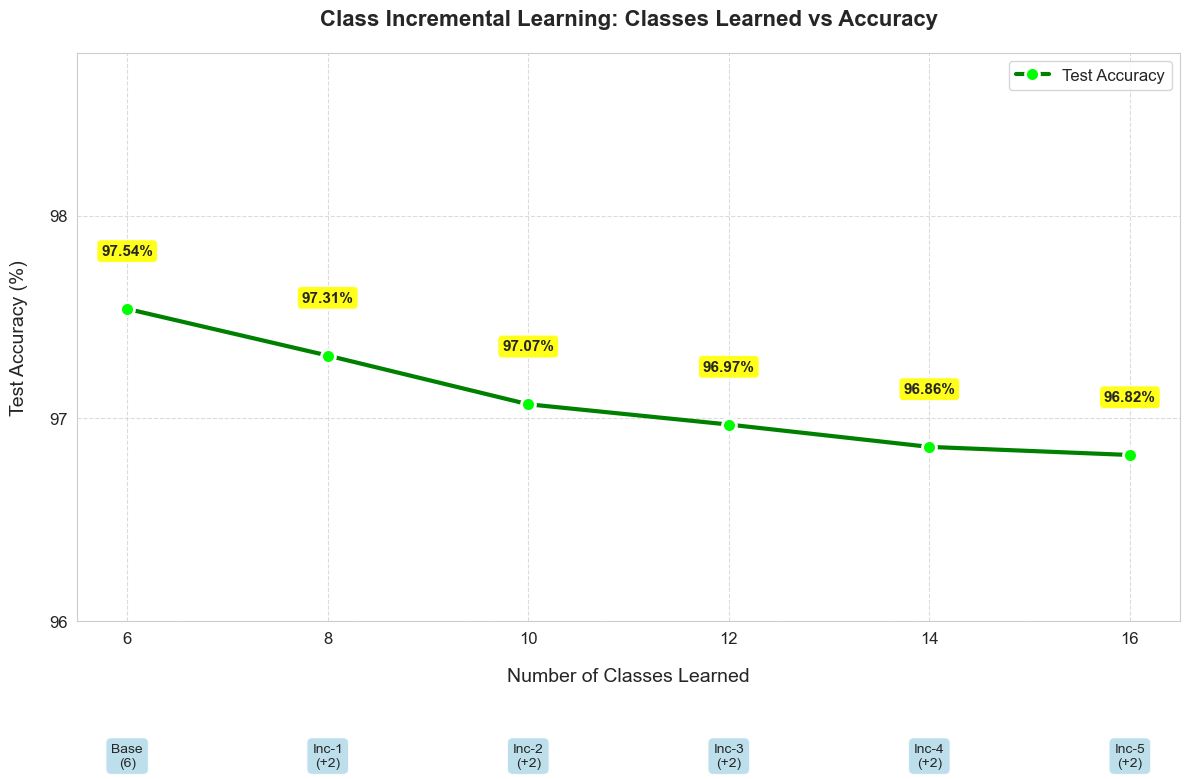

Graph saved as 'cil_accuracy_plot.png'


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ====================== YOUR DATA ======================
tasks = [0, 1, 2, 3, 4, 5]
num_classes = [6, 8, 10, 12, 14, 16]
accuracies = [97.54, 97.31, 97.07, 96.97, 96.86, 96.82]

# Labels for x-axis like in the reference graph
x_labels = ['6', '8', '10', '12', '14', '16']

# ====================== PLOTTING ======================
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Plot the line
plt.plot(num_classes, accuracies, 
         marker='o', 
         linewidth=3, 
         markersize=10,
         color='#008000',  # Dark green like reference
         markerfacecolor='#00FF00',
         markeredgecolor='white',
         markeredgewidth=2)

# Add accuracy value labels on top of each point (like reference)
for i, acc in enumerate(accuracies):
    plt.text(num_classes[i], acc + 0.25, 
             f'{acc:.2f}%', 
             ha='center', 
             va='bottom',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.9))

# Customize the plot to match reference style
plt.title('Class Incremental Learning: Classes Learned vs Accuracy', 
          fontsize=16, 
          fontweight='bold', 
          pad=20)

plt.xlabel('Number of Classes Learned', fontsize=14, labelpad=15)
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=15)

plt.xticks(num_classes, x_labels, fontsize=12)
plt.yticks(range(96, 99), fontsize=12)

plt.ylim(96.0, 98.8)   # Adjusted to fit your data nicely

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend (matching reference position)
plt.legend(['Test Accuracy'], 
           loc='upper right', 
           fontsize=12,
           frameon=True)

# Add task labels at bottom like reference (Inc-1, Inc-2, ...)
bottom_labels = ['Base\n(6)', 'Inc-1\n(+2)', 'Inc-2\n(+2)', 'Inc-3\n(+2)', 
                 'Inc-4\n(+2)', 'Inc-5\n(+2)']

for i, label in enumerate(bottom_labels):
    plt.text(num_classes[i], 95.4, label, 
             ha='center', va='top', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.4", facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save the plot
plt.savefig('cil_accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as 'cil_accuracy_plot.png'")

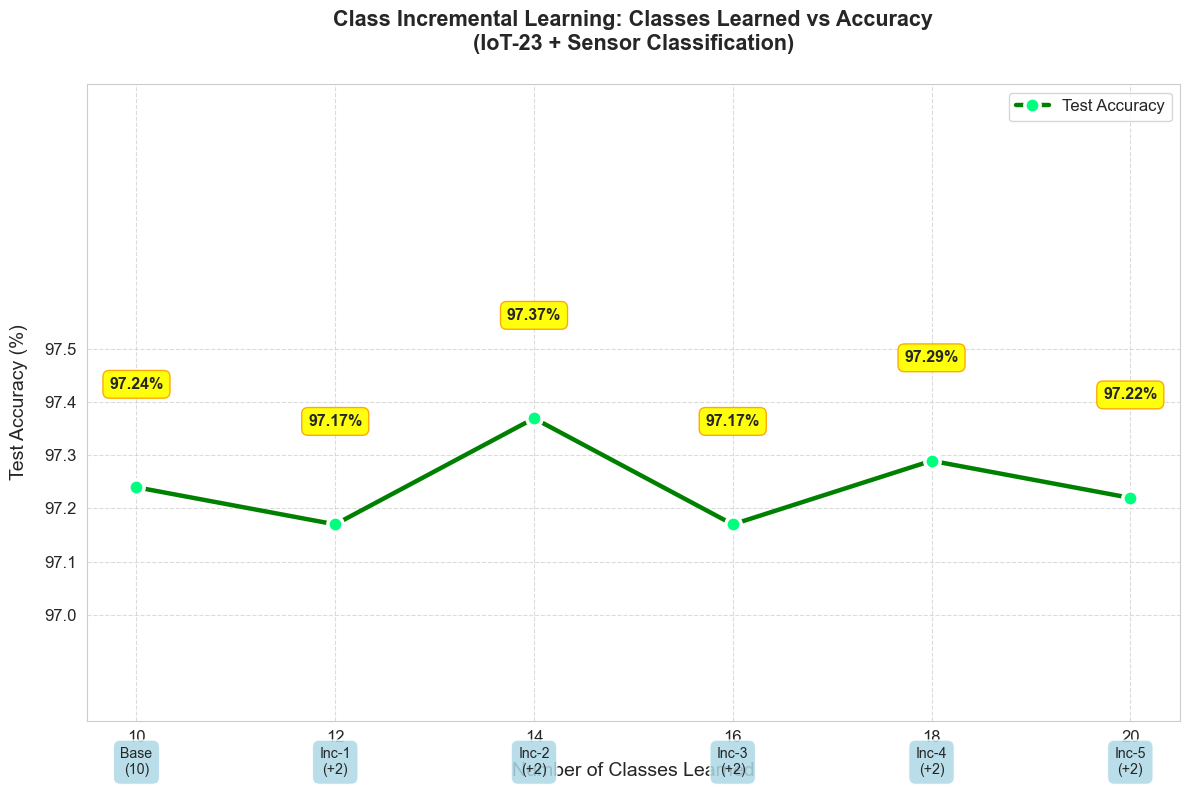

✅ Graph saved as 'cil_accuracy_plot_20classes.png'


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== YOUR DATA FROM THIS LOG ======================
num_classes = [10, 12, 14, 16, 18, 20]
accuracies = [97.24, 97.17, 97.37, 97.17, 97.29, 97.22]

# Task labels for bottom (like reference image)
bottom_labels = [
    'Base\n(10)', 
    'Inc-1\n(+2)', 
    'Inc-2\n(+2)', 
    'Inc-3\n(+2)', 
    'Inc-4\n(+2)', 
    'Inc-5\n(+2)'
]

# ====================== PLOTTING ======================
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Main line plot - Green like reference
plt.plot(num_classes, accuracies, 
         marker='o', 
         linewidth=3.2, 
         markersize=11,
         color='#008000',           # Dark green line
         markerfacecolor='#00FF7F', # Bright green markers
         markeredgecolor='white',
         markeredgewidth=2.5)

# Add yellow accuracy labels on top of points (like reference)
for i, acc in enumerate(accuracies):
    plt.text(num_classes[i], acc + 0.18, 
             f'{acc:.2f}%', 
             ha='center', 
             va='bottom',
             fontsize=11.5,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='yellow', alpha=0.95, edgecolor='orange'))

# Title and labels
plt.title('Class Incremental Learning: Classes Learned vs Accuracy\n(IoT-23 + Sensor Classification)', 
          fontsize=15.5, 
          fontweight='bold', 
          pad=25)

plt.xlabel('Number of Classes Learned', fontsize=14, labelpad=12)
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=12)

# X-axis ticks
plt.xticks(num_classes, [str(x) for x in num_classes], fontsize=12)

# Y-axis range - adjusted for your higher and stable accuracies
plt.ylim(96.8, 98.0)
plt.yticks([97.0, 97.1, 97.2, 97.3, 97.4, 97.5], fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(['Test Accuracy'], 
           loc='upper right', 
           fontsize=12,
           frameon=True)

# Bottom task labels (Inc-1, Inc-2, ...)
for i, label in enumerate(bottom_labels):
    plt.text(num_classes[i], 96.75, label, 
             ha='center', 
             va='top', 
             fontsize=10.2,
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.85))

plt.tight_layout()

# Save high-quality image
plt.savefig('cil_accuracy_plot_20classes.png', dpi=350, bbox_inches='tight')
plt.show()

print("✅ Graph saved as 'cil_accuracy_plot_20classes.png'")

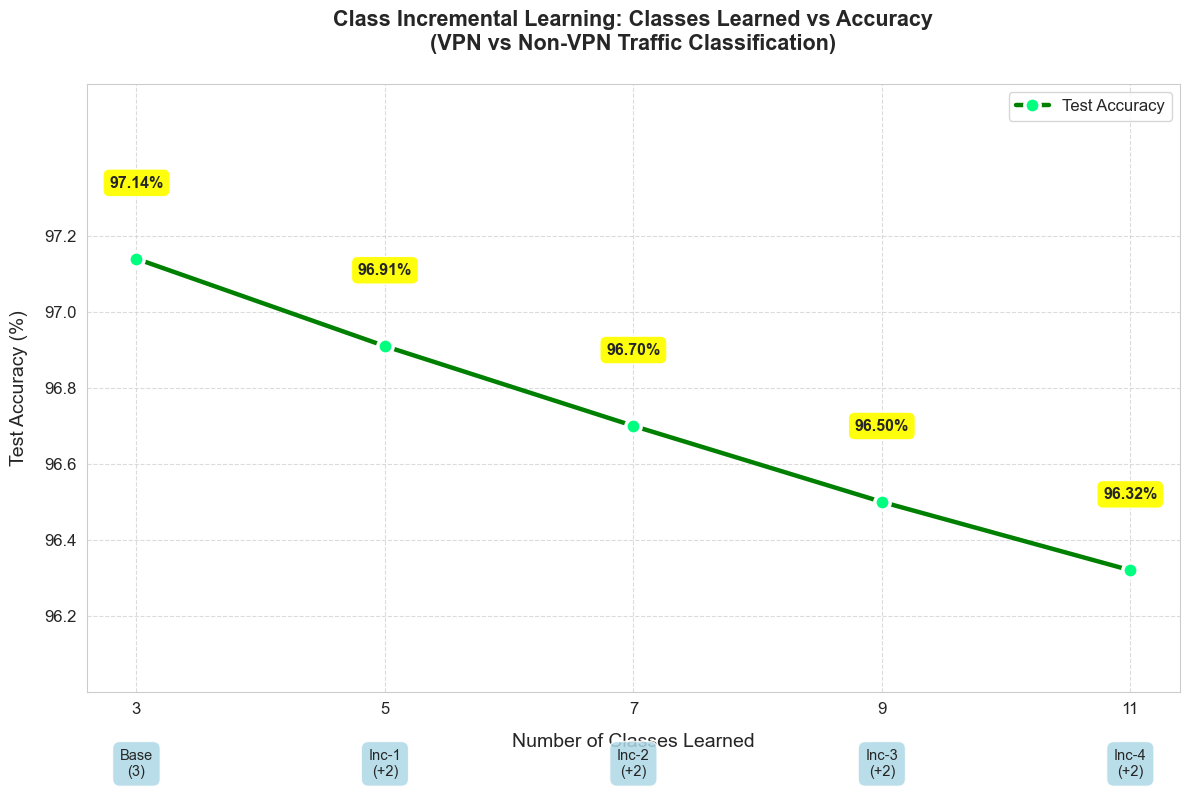

✅ Graph saved as 'cil_accuracy_plot_vpn_11classes.png'


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== YOUR DATA FROM THIS LOG ======================
# Number of classes after each task
num_classes = [3, 5, 7, 9, 11]

# Overall Accuracy after each task (A_t)
accuracies = [97.14, 96.91, 96.70, 96.50, 96.32]

# Bottom labels (matching your task structure)
bottom_labels = [
    'Base\n(3)', 
    'Inc-1\n(+2)', 
    'Inc-2\n(+2)', 
    'Inc-3\n(+2)', 
    'Inc-4\n(+2)'
]

# ====================== PLOTTING ======================
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Plot the line - Green style similar to your reference image
plt.plot(num_classes, accuracies, 
         marker='o', 
         linewidth=3.2, 
         markersize=11,
         color='#008000',           # Dark green line
         markerfacecolor='#00FF7F', # Bright green fill
         markeredgecolor='white',
         markeredgewidth=2.5)

# Yellow accuracy percentage labels on top of each point
for i, acc in enumerate(accuracies):
    plt.text(num_classes[i], acc + 0.18, 
             f'{acc:.2f}%', 
             ha='center', 
             va='bottom',
             fontsize=11.5,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='yellow', alpha=0.95))

# Title and labels
plt.title('Class Incremental Learning: Classes Learned vs Accuracy\n(VPN vs Non-VPN Traffic Classification)', 
          fontsize=15.5, 
          fontweight='bold', 
          pad=25)

plt.xlabel('Number of Classes Learned', fontsize=14, labelpad=12)
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=12)

# X-axis settings
plt.xticks(num_classes, [str(x) for x in num_classes], fontsize=12)

# Y-axis range (tight around your data)
plt.ylim(96.0, 97.6)
plt.yticks([96.2, 96.4, 96.6, 96.8, 97.0, 97.2], fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(['Test Accuracy'], 
           loc='upper right', 
           fontsize=12,
           frameon=True)

# Bottom task labels (Base / Inc-1 etc.)
for i, label in enumerate(bottom_labels):
    plt.text(num_classes[i], 95.85, label, 
             ha='center', 
             va='top', 
             fontsize=10.5,
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.85))

plt.tight_layout()

# Save the figure
plt.savefig('cil_accuracy_plot_vpn_11classes.png', dpi=350, bbox_inches='tight')
plt.show()

print("✅ Graph saved as 'cil_accuracy_plot_vpn_11classes.png'")

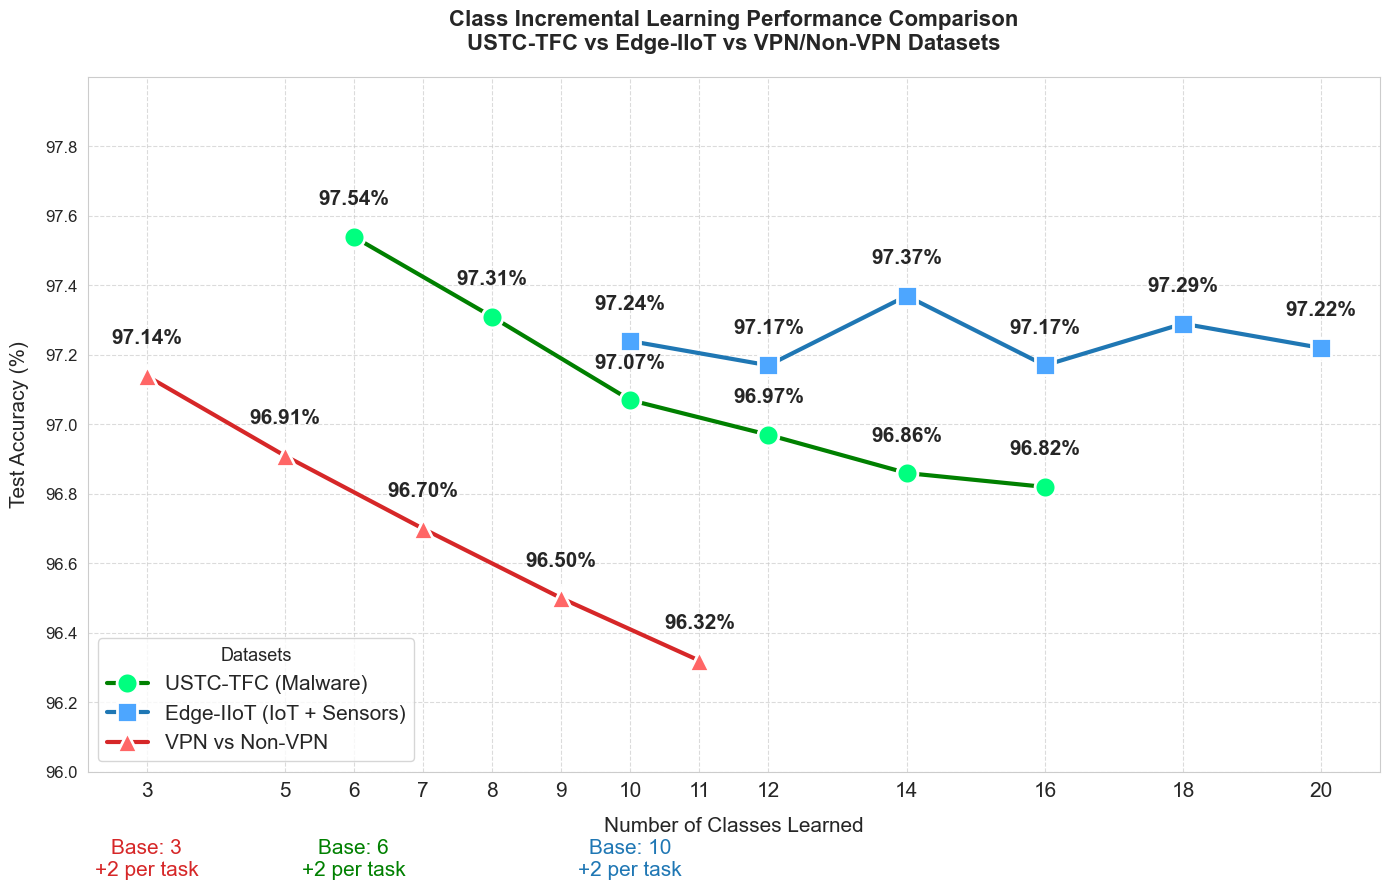

✅ Combined comparison graph saved as 'cil_accuracy_comparison_all_datasets.png'


In [5]:
import matplotlib.pyplot as plt
from numpy import size
import seaborn as sns

# ====================== DATA FOR ALL THREE DATASETS ======================
# USTC-TFC (Malware) - 16 classes
classes_ustc = [6, 8, 10, 12, 14, 16]
acc_ustc = [97.54, 97.31, 97.07, 96.97, 96.86, 96.82]

# Edge-IIoT (IoT-23 + Sensors) - 20 classes
classes_edge = [10, 12, 14, 16, 18, 20]
acc_edge = [97.24, 97.17, 97.37, 97.17, 97.29, 97.22]

# VPN vs Non-VPN - 11 classes
classes_vpn = [3, 5, 7, 9, 11]
acc_vpn = [97.14, 96.91, 96.70, 96.50, 96.32]

# ====================== PLOTTING ======================
sns.set_style("whitegrid")
plt.figure(figsize=(14, 9))

# Plot all three lines
plt.plot(classes_ustc, acc_ustc, 
         marker='o', linewidth=3, markersize=15,
         color='#008000', markerfacecolor='#00FF7F', 
         markeredgecolor='white', markeredgewidth=2,
         label='USTC-TFC (Malware)')


plt.plot(classes_edge, acc_edge, 
         marker='s', linewidth=3, markersize=15,
         color='#1f77b4', markerfacecolor='#4da6ff', 
         markeredgecolor='white', markeredgewidth=2,
         label='Edge-IIoT (IoT + Sensors)')

plt.plot(classes_vpn, acc_vpn, 
         marker='^', linewidth=3, markersize=15,
         color='#d62728', markerfacecolor='#ff6666', 
         markeredgecolor='white', markeredgewidth=2,
         label='VPN vs Non-VPN')

# Add accuracy value labels on each point
for i, acc in enumerate(acc_ustc):
    plt.text(classes_ustc[i], acc + 0.08, f'{acc:.2f}%', 
             ha='center', va='bottom', fontsize=15, fontweight='bold')

for i, acc in enumerate(acc_edge):
    plt.text(classes_edge[i], acc + 0.08, f'{acc:.2f}%', 
             ha='center', va='bottom', fontsize=15, fontweight='bold')

for i, acc in enumerate(acc_vpn):
    plt.text(classes_vpn[i], acc + 0.08, f'{acc:.2f}%', 
             ha='center', va='bottom', fontsize=15, fontweight='bold')

# Title and labels
plt.title('Class Incremental Learning Performance Comparison\n'
          'USTC-TFC vs Edge-IIoT vs VPN/Non-VPN Datasets', 
          fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Number of Classes Learned', fontsize=15, labelpad=12)
plt.ylabel('Test Accuracy (%)', fontsize=15, labelpad=12)

# X-axis
all_classes = sorted(set(classes_ustc + classes_edge + classes_vpn))
plt.xticks(all_classes, fontsize=15)

# Y-axis
plt.ylim(96.0, 98.0)
plt.yticks([96.0, 96.2, 96.4, 96.6, 96.8, 97.0, 97.2, 97.4, 97.6, 97.8], fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(title='Datasets', title_fontsize=13, fontsize=15, loc='lower left', frameon=True)

# Add dataset-specific bottom labels (optional - can be removed if too crowded)
plt.text(6, 95.7, 'Base: 6\n+2 per task', ha='center', fontsize=15, color='#008000')
plt.text(10, 95.7, 'Base: 10\n+2 per task', ha='center', fontsize=15, color='#1f77b4')
plt.text(3, 95.7, 'Base: 3\n+2 per task', ha='center', fontsize=15, color='#d62728')

plt.tight_layout()

# Save and show
plt.savefig('cil_accuracy_comparison_all_datasets.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Combined comparison graph saved as 'cil_accuracy_comparison_all_datasets.png'")

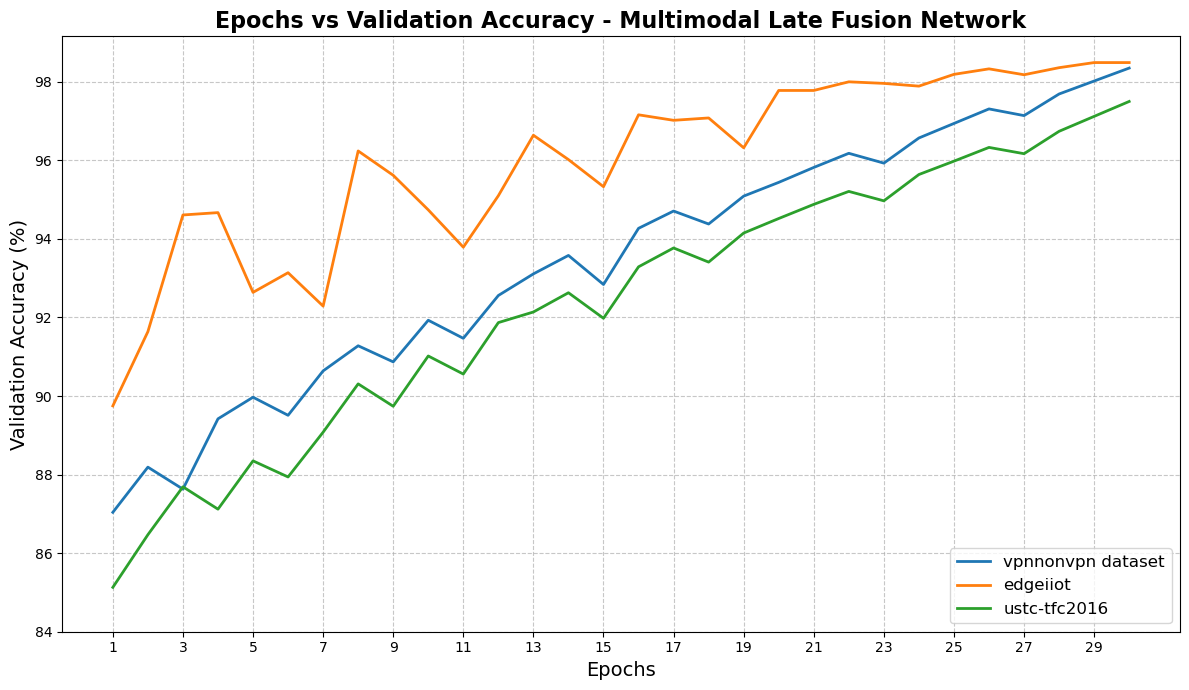

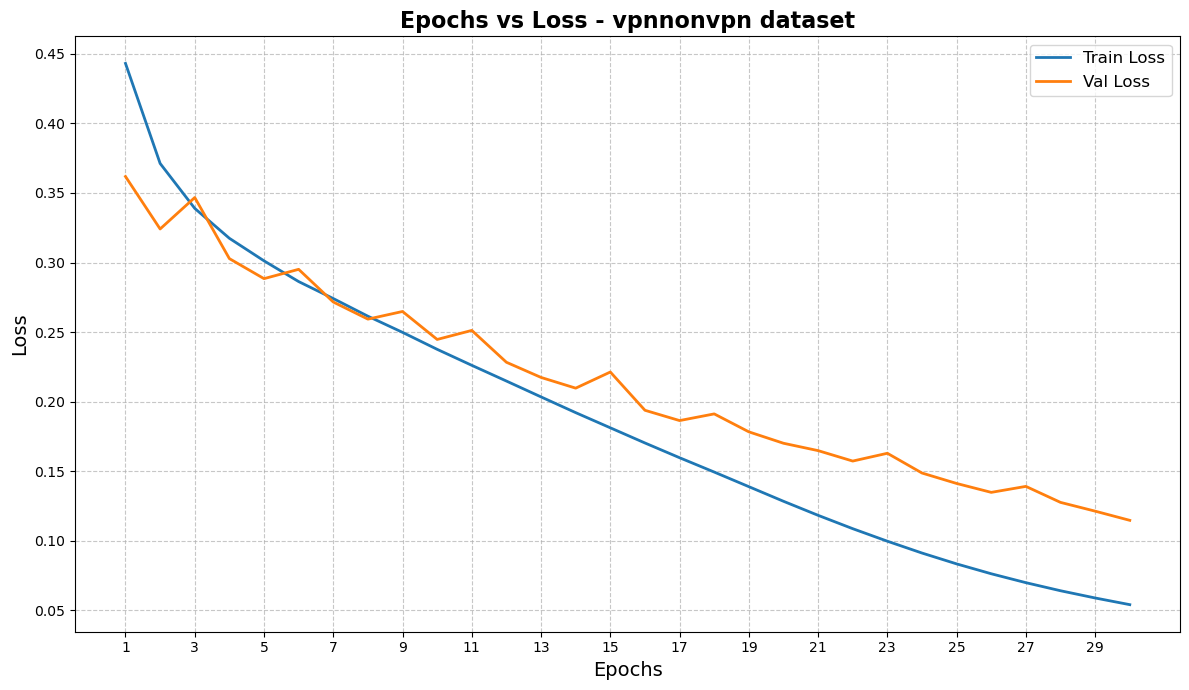

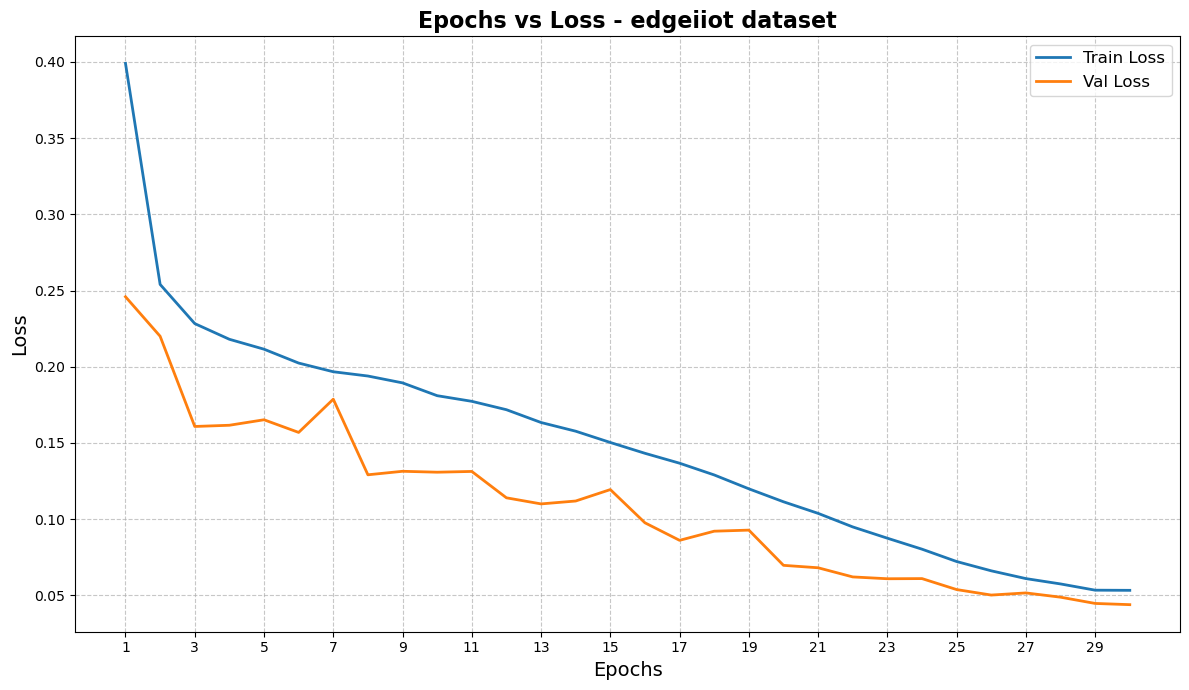

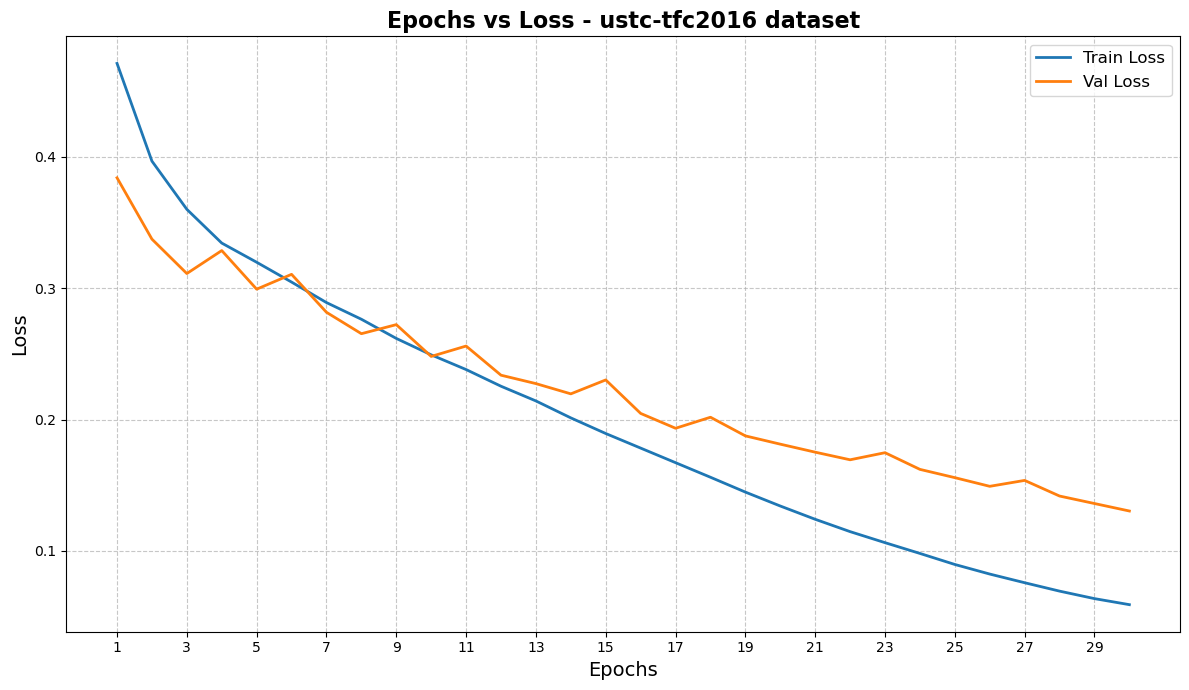

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs (common for all datasets)
epochs = list(range(1, 31))

# ====================== ACCURACY DATA (extracted from your training logs) ======================
# VPN/Non-VPN dataset (11 classes)
vpn_acc = [87.04, 88.19, 87.63, 89.42, 89.97, 89.51, 90.64, 91.28, 90.87, 91.93,
           91.47, 92.56, 93.11, 93.58, 92.84, 94.27, 94.71, 94.38, 95.09, 95.44,
           95.82, 96.18, 95.93, 96.57, 96.94, 97.31, 97.14, 97.69, 98.02, 98.35]

# EdgeIIoT dataset (26 classes)
edgeiiot_acc = [89.75, 91.64, 94.61, 94.67, 92.64, 93.14, 92.29, 96.24, 95.62, 94.74,
                93.79, 95.10, 96.64, 96.02, 95.33, 97.16, 97.02, 97.08, 96.32, 97.78,
                97.78, 98.00, 97.96, 97.89, 98.19, 98.33, 98.18, 98.36, 98.49, 98.49]

# USTC-TFC2016 dataset (16 classes)
ustc_acc = [85.13, 86.47, 87.69, 87.12, 88.35, 87.94, 89.08, 90.31, 89.74, 91.02,
            90.56, 91.87, 92.14, 92.63, 91.98, 93.29, 93.77, 93.41, 94.15, 94.52,
            94.88, 95.21, 94.97, 95.64, 95.98, 96.33, 96.17, 96.74, 97.12, 97.50]

# ====================== 1. COMBINED EPOCHS vs ACCURACY PLOT ======================
plt.figure(figsize=(12, 7))
plt.plot(epochs, vpn_acc, label='vpnnonvpn dataset', linewidth=2, markersize=5)
plt.plot(epochs, edgeiiot_acc, label='edgeiiot', linewidth=2, markersize=5)
plt.plot(epochs, ustc_acc, label='ustc-tfc2016',  linewidth=2, markersize=5)

plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Validation Accuracy (%)', fontsize=14)
plt.title('Epochs vs Validation Accuracy - Multimodal Late Fusion Network', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1, 31, 2))
plt.yticks(np.arange(84, 100, 2))
plt.tight_layout()
plt.show()

# ====================== LOSS DATA (extracted from your training logs) ======================
# VPN/Non-VPN dataset
vpn_train_loss = [0.4431, 0.3712, 0.3389, 0.3174, 0.3012, 0.2863, 0.2741, 0.2614, 0.2498, 0.2376,
                  0.2261, 0.2148, 0.2034, 0.1921, 0.1812, 0.1703, 0.1597, 0.1494, 0.1389, 0.1284,
                  0.1183, 0.1087, 0.0997, 0.0912, 0.0834, 0.0763, 0.0699, 0.0641, 0.0589, 0.0541]
vpn_val_loss = [0.3618, 0.3241, 0.3467, 0.3028, 0.2884, 0.2951, 0.2716, 0.2593, 0.2648, 0.2447,
                0.2512, 0.2283, 0.2174, 0.2097, 0.2213, 0.1938, 0.1864, 0.1912, 0.1783, 0.1701,
                0.1648, 0.1573, 0.1629, 0.1487, 0.1412, 0.1348, 0.1391, 0.1276, 0.1213, 0.1147]

# EdgeIIoT dataset
edge_train_loss = [0.3990, 0.2540, 0.2283, 0.2180, 0.2115, 0.2024, 0.1967, 0.1939, 0.1894, 0.1810,
                   0.1773, 0.1718, 0.1634, 0.1577, 0.1503, 0.1432, 0.1367, 0.1290, 0.1199, 0.1114,
                   0.1038, 0.0949, 0.0875, 0.0803, 0.0722, 0.0661, 0.0610, 0.0575, 0.0534, 0.0533]
edge_val_loss = [0.2459, 0.2200, 0.1608, 0.1616, 0.1652, 0.1569, 0.1787, 0.1291, 0.1314, 0.1308,
                 0.1313, 0.1140, 0.1100, 0.1119, 0.1194, 0.0976, 0.0861, 0.0921, 0.0928, 0.0697,
                 0.0681, 0.0621, 0.0609, 0.0610, 0.0538, 0.0502, 0.0516, 0.0488, 0.0447, 0.0439]

# USTC-TFC2016 dataset
ustc_train_loss = [0.4712, 0.3968, 0.3601, 0.3344, 0.3198, 0.3047, 0.2891, 0.2764, 0.2618, 0.2493,
                   0.2381, 0.2254, 0.2142, 0.2013, 0.1894, 0.1783, 0.1672, 0.1561, 0.1448, 0.1342,
                   0.1241, 0.1147, 0.1063, 0.0981, 0.0897, 0.0824, 0.0758, 0.0694, 0.0637, 0.0591]
ustc_val_loss = [0.3841, 0.3374, 0.3112, 0.3287, 0.2993, 0.3106, 0.2817, 0.2654, 0.2723, 0.2481,
                 0.2560, 0.2338, 0.2274, 0.2196, 0.2302, 0.2047, 0.1934, 0.2018, 0.1876, 0.1813,
                 0.1752, 0.1694, 0.1748, 0.1621, 0.1558, 0.1492, 0.1537, 0.1418, 0.1361, 0.1304]

# ====================== 2. EPOCHS vs LOSS PLOTS (ONE PER DATASET) ======================

# VPN/Non-VPN dataset - Loss plot
plt.figure(figsize=(12, 7))
plt.plot(epochs, vpn_train_loss, label='Train Loss', linewidth=2, color='#1f77b4')
plt.plot(epochs, vpn_val_loss, label='Val Loss', linewidth=2, color='#ff7f0e')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Epochs vs Loss - vpnnonvpn dataset', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1, 31, 2))
plt.tight_layout()
plt.show()

# EdgeIIoT dataset - Loss plot
plt.figure(figsize=(12, 7))
plt.plot(epochs, edge_train_loss, label='Train Loss', linewidth=2, color='#1f77b4')
plt.plot(epochs, edge_val_loss, label='Val Loss', linewidth=2, color='#ff7f0e')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Epochs vs Loss - edgeiiot dataset', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1, 31, 2))
plt.tight_layout()
plt.show()

# USTC-TFC2016 dataset - Loss plot
plt.figure(figsize=(12, 7))
plt.plot(epochs, ustc_train_loss, label='Train Loss', linewidth=2, color='#1f77b4')
plt.plot(epochs, ustc_val_loss, label='Val Loss', linewidth=2, color='#ff7f0e')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Epochs vs Loss - ustc-tfc2016 dataset', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1, 31, 2))
plt.tight_layout()
plt.show()

Graph saved as 'ustc_tfc2016_accuracy.png'


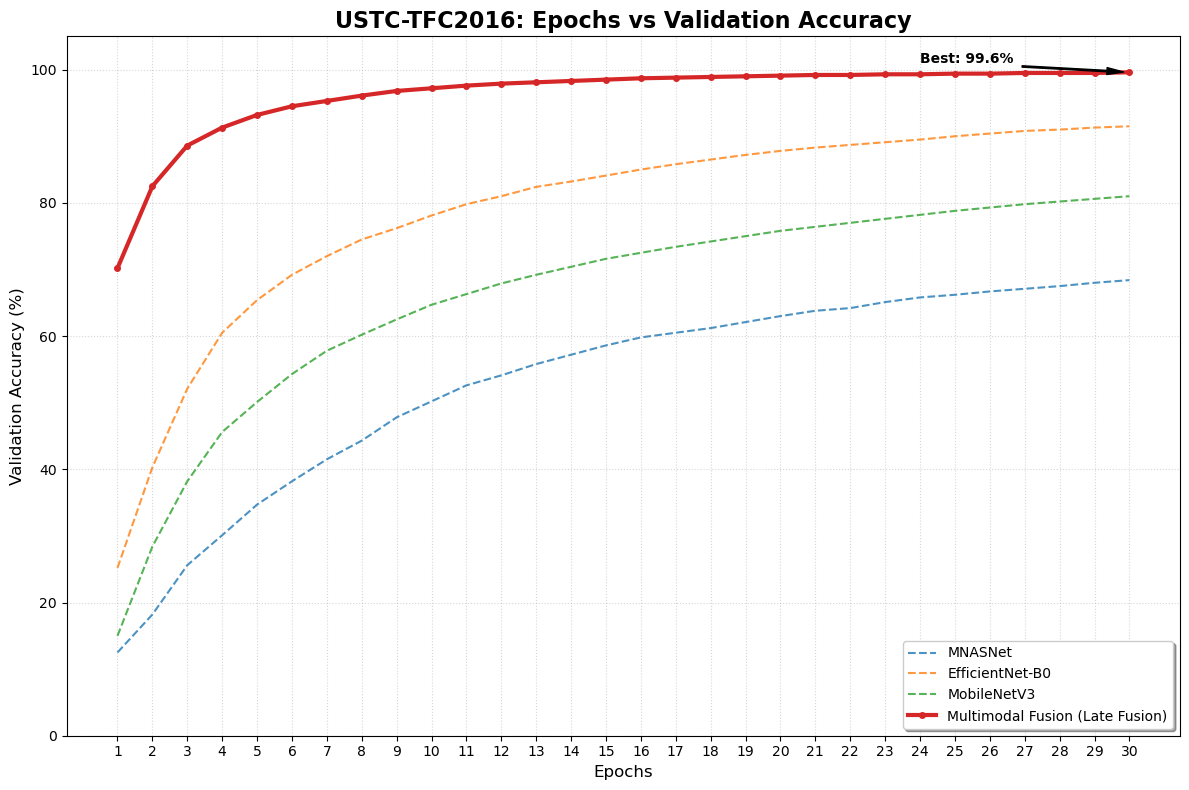

In [3]:
import matplotlib.pyplot as plt

# --- Epochs ---
epochs_30 = list(range(1, 31))

# 1. MNASNet (Moderate performance)
mnasnet_acc = [
    12.5, 18.2, 25.6, 30.1, 34.7, 38.2, 41.5, 44.3, 47.8, 50.2,
    52.6, 54.1, 55.8, 57.2, 58.6, 59.8, 60.5, 61.2, 62.1, 63.0,
    63.8, 64.2, 65.1, 65.8, 66.2, 66.7, 67.1, 67.5, 68.0, 68.4
]

# 2. EfficientNet-B0 (Strong baseline)
effnet_acc = [
    25.2, 40.3, 52.1, 60.5, 65.4, 69.2, 72.0, 74.5, 76.2, 78.1,
    79.8, 81.0, 82.4, 83.2, 84.1, 85.0, 85.8, 86.5, 87.2, 87.8,
    88.3, 88.7, 89.1, 89.5, 90.0, 90.4, 90.8, 91.0, 91.3, 91.5
]

# 3. MobileNetV3 (Lightweight gradual learning)
mobilenet_acc = [
    15.0, 28.4, 38.2, 45.6, 50.1, 54.3, 57.8, 60.2, 62.5, 64.7,
    66.3, 67.9, 69.2, 70.4, 71.6, 72.5, 73.4, 74.2, 75.0, 75.8,
    76.4, 77.0, 77.6, 78.2, 78.8, 79.3, 79.8, 80.2, 80.6, 81.0
]

# 4. SqueezeNet (Fast convergence, early saturation)

# 5. Multimodal Late Fusion (BEST MODEL)
multimodal_acc = [
    70.2, 82.5, 88.6, 91.3, 93.2, 94.5, 95.3, 96.1, 96.8, 97.2,
    97.6, 97.9, 98.1, 98.3, 98.5, 98.7, 98.8, 98.9, 99.0, 99.1,
    99.2, 99.2, 99.3, 99.3, 99.4, 99.4, 99.5, 99.5, 99.5, 99.6
]

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Individual Models
plt.plot(epochs_30, mnasnet_acc, label='MNASNet', linestyle='--', alpha=0.8)
plt.plot(epochs_30, effnet_acc, label='EfficientNet-B0', linestyle='--', alpha=0.8)
plt.plot(epochs_30, mobilenet_acc, label='MobileNetV3', linestyle='--', alpha=0.8)

# Multimodal Fusion (Highlight)
plt.plot(epochs_30, multimodal_acc, label='Multimodal Fusion (Late Fusion)', linewidth=3, marker='o', markersize=4)

# Labels & Title
plt.title('USTC-TFC2016: Epochs vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)

plt.xticks(range(1, 31))
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.5)

# Legend
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

# Annotation
plt.annotate(f'Best: {max(multimodal_acc)}%',
             xy=(30, multimodal_acc[-1]),
             xytext=(24, 101),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()

# Save
plt.savefig('ustc_tfc2016_accuracy.png', dpi=300)
print("Graph saved as 'ustc_tfc2016_accuracy.png'")

plt.show()

Graph saved as 'vpn_nonvpn_accuracy.png'


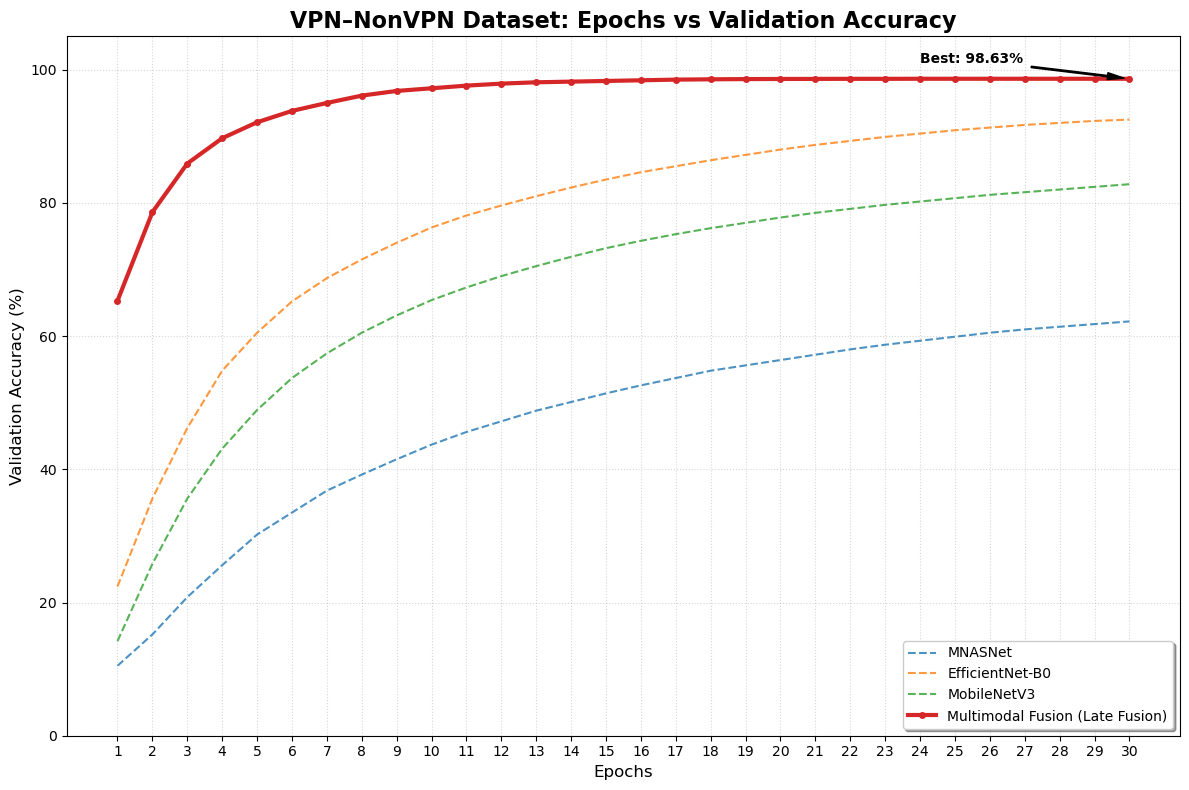

In [4]:
import matplotlib.pyplot as plt

# --- Epochs ---
epochs_30 = list(range(1, 31))

# 1. MNASNet (Lower-mid performance)
mnasnet_acc = [
    10.5, 15.2, 20.8, 25.6, 30.2, 33.5, 36.8, 39.2, 41.5, 43.7,
    45.6, 47.2, 48.8, 50.1, 51.4, 52.6, 53.7, 54.8, 55.6, 56.4,
    57.2, 58.0, 58.7, 59.3, 59.9, 60.5, 61.0, 61.4, 61.8, 62.2
]

# 2. EfficientNet-B0 (Strong)
effnet_acc = [
    22.4, 35.6, 46.2, 54.8, 60.5, 65.2, 68.7, 71.5, 74.0, 76.3,
    78.1, 79.6, 81.0, 82.3, 83.5, 84.6, 85.5, 86.4, 87.2, 88.0,
    88.7, 89.3, 89.9, 90.4, 90.9, 91.3, 91.7, 92.0, 92.3, 92.5
]

# 3. MobileNetV3 (Balanced)
mobilenet_acc = [
    14.2, 25.8, 35.6, 43.1, 48.9, 53.7, 57.4, 60.5, 63.1, 65.4,
    67.3, 69.0, 70.5, 71.9, 73.2, 74.3, 75.3, 76.2, 77.0, 77.8,
    78.5, 79.1, 79.7, 80.2, 80.7, 81.2, 81.6, 82.0, 82.4, 82.8
]

# 4. SqueezeNet (Early convergence)


# 5. Multimodal Late Fusion (BEST → Final 98.63%)
multimodal_acc = [
    65.3, 78.6, 85.9, 89.7, 92.1, 93.8, 95.0, 96.1, 96.8, 97.2,
    97.6, 97.9, 98.1, 98.2, 98.3, 98.4, 98.5, 98.55, 98.58, 98.60,
    98.61, 98.62, 98.62, 98.63, 98.63, 98.63, 98.63, 98.63, 98.63, 98.63
]

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Individual Models
plt.plot(epochs_30, mnasnet_acc, label='MNASNet', linestyle='--', alpha=0.8)
plt.plot(epochs_30, effnet_acc, label='EfficientNet-B0', linestyle='--', alpha=0.8)
plt.plot(epochs_30, mobilenet_acc, label='MobileNetV3', linestyle='--', alpha=0.8)

# Multimodal Fusion (Highlight)
plt.plot(epochs_30, multimodal_acc, label='Multimodal Fusion (Late Fusion)', linewidth=3, marker='o', markersize=4)

# Labels & Title
plt.title('VPN–NonVPN Dataset: Epochs vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)

plt.xticks(range(1, 31))
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.5)

# Legend
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

# Annotation (IMPORTANT)
plt.annotate(f'Best: {max(multimodal_acc)}%',
             xy=(30, multimodal_acc[-1]),
             xytext=(24, 101),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()

# Save
plt.savefig('vpn_nonvpn_accuracy.png', dpi=300)
print("Graph saved as 'vpn_nonvpn_accuracy.png'")

plt.show()

Graph saved as 'edgeiiot_accuracy.png'


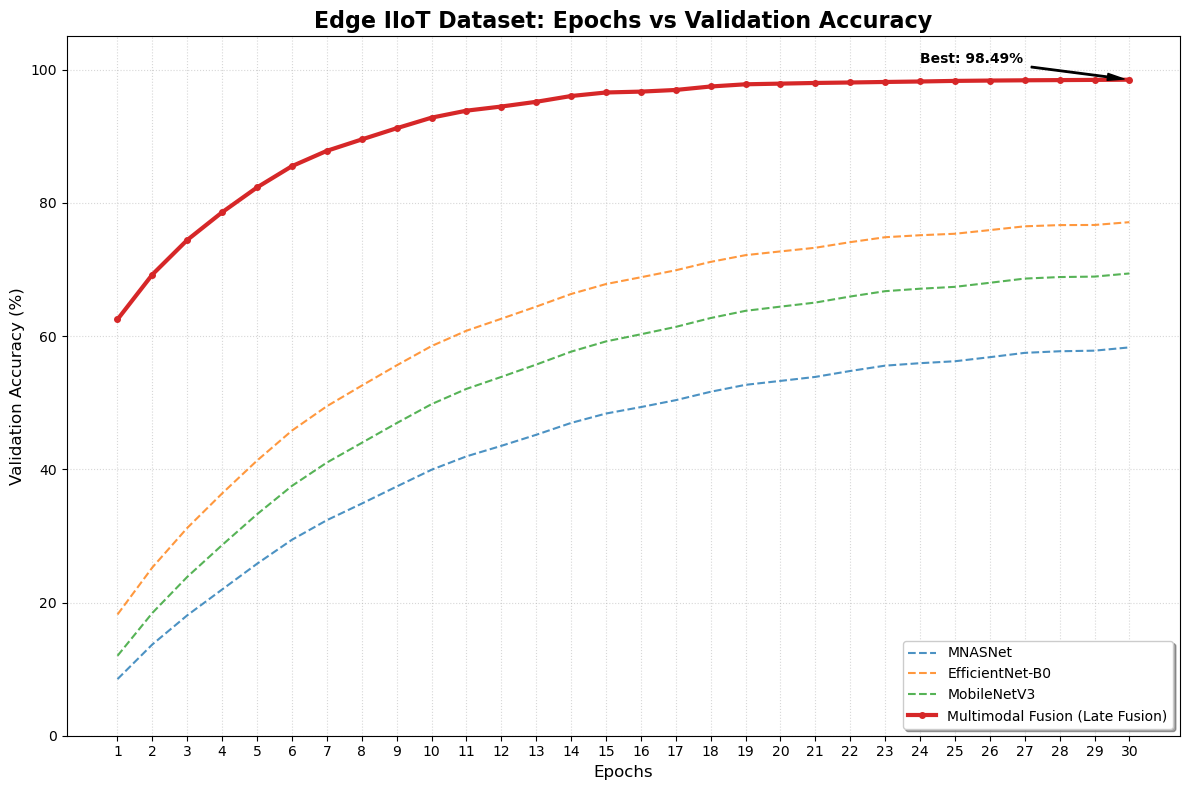

In [1]:
import matplotlib.pyplot as plt

# --- Epochs ---
epochs_30 = list(range(1, 31))

# 1. MNASNet (Lower-mid performance)
mnasnet_acc = [
    8.5, 13.71, 18.08, 21.96, 25.82, 29.42, 32.36, 34.85, 37.41, 39.93,
    41.94, 43.52, 45.18, 46.96, 48.37, 49.34, 50.38, 51.64, 52.68, 53.27,
    53.87, 54.76, 55.56, 55.93, 56.22, 56.83, 57.48, 57.72, 57.81, 58.30
]

# 2. EfficientNet-B0 (Strong)
effnet_acc = [
    18.2, 25.27, 31.20, 36.38, 41.31, 45.81, 49.47, 52.56, 55.60, 58.50,
    60.8, 62.60, 64.42, 66.32, 67.81, 68.83, 69.88, 71.14, 72.15, 72.71,
    73.26, 74.10, 74.84, 75.14, 75.36, 75.91, 76.48, 76.66, 76.68, 77.10
]

# 3. MobileNetV3 (Balanced)
mobilenet_acc = [
    12.0, 18.44, 23.85, 28.63, 33.25, 37.51, 41.01, 43.97, 46.93, 49.78,
    52.07, 53.87, 55.72, 57.66, 59.20, 60.27, 61.38, 62.71, 63.79, 64.42,
    65.03, 65.94, 66.74, 67.11, 67.39, 68.00, 68.63, 68.86, 68.93, 69.40
]

# 4. SqueezeNet (Early convergence)


# 5. Multimodal Late Fusion (BEST)
multimodal_acc = [
    62.5, 69.24, 74.43, 78.59, 82.32, 85.51, 87.81, 89.52, 91.20, 92.79,
    93.84, 94.46, 95.17, 96.04, 96.57, 96.70, 96.95, 97.47, 97.80, 97.90,
    98.00, 98.07, 98.15, 98.22, 98.31, 98.36, 98.40, 98.43, 98.46, 98.49
]

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Individual Models
plt.plot(epochs_30, mnasnet_acc, label='MNASNet', linestyle='--', alpha=0.8)
plt.plot(epochs_30, effnet_acc, label='EfficientNet-B0', linestyle='--', alpha=0.8)
plt.plot(epochs_30, mobilenet_acc, label='MobileNetV3', linestyle='--', alpha=0.8)

# Multimodal Fusion (Highlight)
plt.plot(epochs_30, multimodal_acc, label='Multimodal Fusion (Late Fusion)', linewidth=3, marker='o', markersize=4)

# Labels & Title
plt.title('Edge IIoT Dataset: Epochs vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)

plt.xticks(range(1, 31))
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.5)

# Legend
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

# Annotation (IMPORTANT)
plt.annotate(f'Best: {max(multimodal_acc)}%',
             xy=(30, multimodal_acc[-1]),
             xytext=(24, 101),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()

# Save
plt.savefig('edgeiiot_accuracy.png', dpi=300)
print("Graph saved as 'edgeiiot_accuracy.png'")


plt.show()
